In [3]:
import numpy as np

 ## Các phép toán trên vector và ma trận

In [4]:
def compute_vector_length(vector: np.ndarray) -> float:
  length_of_vector = np.sqrt(vector.dot(vector.T))
  return length_of_vector
#test
ex1_vector_1 = np.array([3,4])

print(compute_vector_length(ex1_vector_1)) #expected result: 5


5.0


In [5]:
def compute_dot_product(vector1: np.ndarray, vector2: np.ndarray) -> float:
  return vector1.dot(vector2)

#test
ex2_vector_1 = np.array([[3,4],[4,5]])
ex2_vector_2 = np.array([[1,2],[1,2]])

print(compute_dot_product(ex2_vector_1, ex2_vector_2))



[[ 7 14]
 [ 9 18]]


In [6]:
def matrix_multi_vector(matrix: np.ndarray, vector: np.ndarray) -> np.ndarray:
  return matrix.dot(vector)

ex3_matrix_1 = np.array([[3,4],[4,5]])
ex3_vector_1 = np.array([3,5])

print(matrix_multi_vector(ex3_matrix_1, ex3_vector_1))


[29 37]


In [7]:
def matrix_multi_matrix (matrix1: np.ndarray, matrix2: np.ndarray) -> np.ndarray:
  return matrix1.dot(matrix2)

ex4_matrix_1 = np.array([[3,4],[4,5]])
ex4_matrix_2 = np.array([[3,5], [6,3]])

print(matrix_multi_matrix(ex4_matrix_1, ex4_matrix_2))

[[33 27]
 [42 35]]


## Cosine similarity

In [8]:
x = np.array([1,2,3,4])
y = np.array([1,0,3,0])

def compute_cosine(x: np.ndarray, y: np.ndarray) -> float:
  #compute length x, y
  length_x = compute_vector_length(x)
  length_y = compute_vector_length(y)
  #compute cos_sim
  cos_sim = x.dot(y) / (length_x * length_y)
  return cos_sim

print(compute_cosine(x,y))


0.5773502691896257


## Background subtraction




In [9]:
from google.colab.patches import cv2_imshow
import cv2

bg1_image = cv2.imread("GreenBackground.png", 1)
bg1_image = cv2.resize(bg1_image, (678,381))

ob_image = cv2.imread("Object.png", 1)
ob_image = cv2.resize(ob_image, (678,381))

bg2_image = cv2.imread("NewBackground.jpg", 1)
bg2_image = cv2.resize(bg2_image, (678,381))



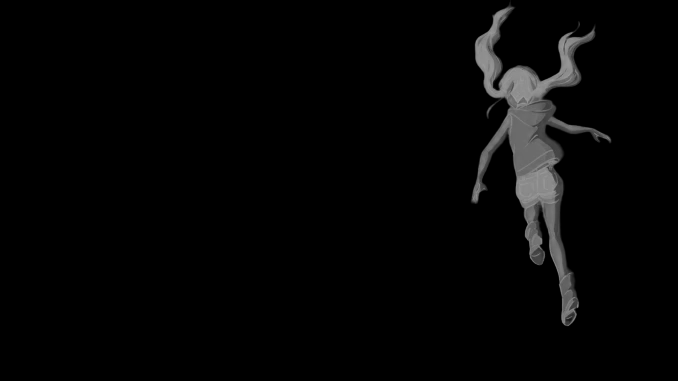

In [10]:
def compute_difference(bg_img: np.ndarray, input_img: np.ndarray) -> np.ndarray:
  # Compute difference
  difference_single_channel = cv2.absdiff(bg_img, input_img)

  conv_vector = np.array([0.072, 0.715, 0.213])
  difference_single_channel = difference_single_channel@conv_vector

  return difference_single_channel

difference_single_channel = compute_difference(bg1_image, ob_image)
cv2_imshow(difference_single_channel)

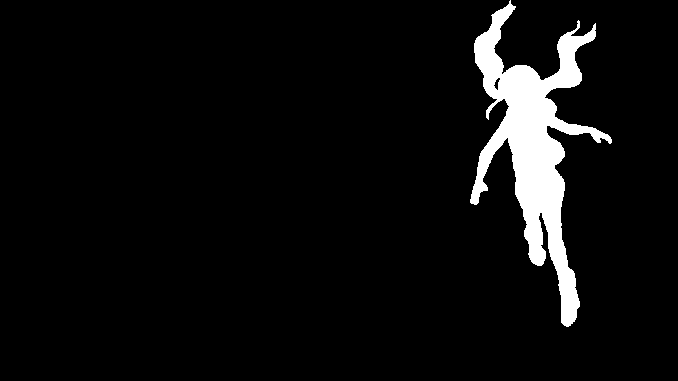

In [11]:
def compute_binary_mask(difference_single_channel: np.ndarray) -> np.ndarray:
  difference_binary = (np.where(difference_single_channel > 0, 255, 0))
  return difference_binary

binary_mask = compute_binary_mask(difference_single_channel)

cv2_imshow(binary_mask)


In [12]:
def replace_background(bg1_image, bg2_image, ob_image):
  difference_single_channel = compute_difference(
      bg1_image,
      ob_image)

  binary_mask = compute_binary_mask(difference_single_channel)

  output = np.where(binary_mask[:, :, np.newaxis]==255, ob_image, bg2_image)
  return output

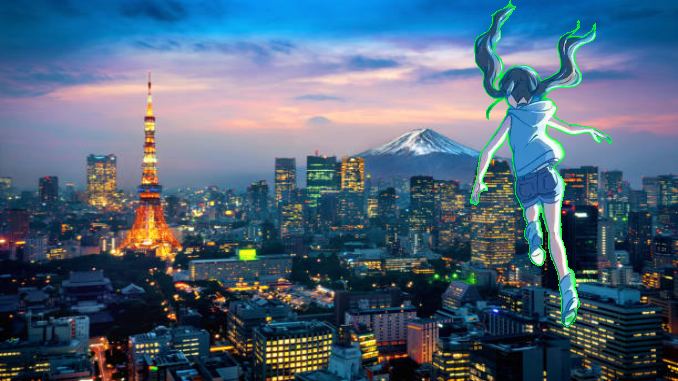

In [13]:
output = replace_background(bg1_image, bg2_image, ob_image)
cv2_imshow(output)

## Trắc nghiệm

In [14]:
# Câu 1
vector= np.array([-2,4,9,21])

result= compute_vector_length(vector)
print(round(result,2))

23.28


In [15]:
# Câu 2
v1=np.array([0,1,-1,2])
v2=np.array([2,5,1,0])
result= compute_dot_product(v1,v2)
print(round(result,2))

4


In [16]:
# Câu 3
matrix= np.array([[-1,1,1],[0,-4,9]])
vector= np.array([0,2,1])
result= matrix_multi_vector(matrix,vector)
print(result)



[3 1]


In [17]:
# Câu 4
m1=np.array([[0,1,2],[2,-3,1]])
m2=np.array([[1,-3],[6,1],[0,-1]])
result= matrix_multi_matrix(m1,m2)
print(result)

[[  6  -1]
 [-16 -10]]


In [18]:
# Câu 5
x=np.array([1,2,3,4])
y=np.array([1,0,3,0])
result= compute_cosine(x,y)
print(round(result,3))

0.577


In [19]:
# Câu 6: Lọc số lẻ
arr = np.arange(0, 10)

def filter_odd_number(numbers: np.ndarray) -> np.ndarray:
  return ((numbers % 2) != 0)

print(arr[filter_odd_number(arr)])

[1 3 5 7 9]


In [20]:
# Câu 7: Thay số lẻ = -1
arr = np.arange(0, 10)

arr = [-1 if (arr[i] % 2 != 0 ) else i for i in arr]

print(arr)


[np.int64(0), -1, np.int64(2), -1, np.int64(4), -1, np.int64(6), -1, np.int64(8), -1]


In [27]:
# Câu 8: Gộp mảng theo trục axis = 0
arr1 = np.arange(10).reshape(2,-1)
arr2 = np.ones((2,5), dtype = "int")
c = np.vstack((arr1,arr2))

print(c)


[[0 1 2 3 4]
 [5 6 7 8 9]
 [1 1 1 1 1]
 [1 1 1 1 1]]


In [28]:
# Câu 9 : axis = 1
arr1 = np.arange(10).reshape(2,-1)
arr2 = np.ones((2,5), dtype = "int")
c = np.hstack((arr1,arr2))

print(c)

[[0 1 2 3 4 1 1 1 1 1]
 [5 6 7 8 9 1 1 1 1 1]]


In [46]:
#Câu 10 Lọc giá trị theo điều kiện:
a = np.array([2, 6, 1, 9, 10, 3, 27])
# điều kiện phần tử >= 5 và <= 10
index = []
for idx in range(len(a)):
  if (a[idx] >= 5 and  a[idx] <= 10):
    index.append(idx)

a[index]


array([ 6,  9, 10])

## Xử lý ảnh


In [47]:
!gdown 1i9dqan21DjQoG5Q_VEvm0LrVwAlXD0vB
import matplotlib.image as mpimg
import numpy as np
img = mpimg.imread("/content/dog.jpeg")

Downloading...
From: https://drive.google.com/uc?id=1i9dqan21DjQoG5Q_VEvm0LrVwAlXD0vB
To: /content/dog.jpeg
100% 33.7k/33.7k [00:00<00:00, 67.9MB/s]


In [48]:
img.shape

(534, 800, 3)

In [53]:
#Câu 11
# Sử dụng công thức Lightness: (max(R,G,B) + min(R,G,B))/2
gray_img_01 = (np.max(img, axis = 2) + np.min(img, axis = 2)) / 2

print(gray_img_01[0, 0])

102.5


In [56]:
# Câu 12
# Sử dụng công thức Average: (R+G+B)/3

gray_img_02 = np.average(img, axis=2)

print(gray_img_02[0, 0])

107.66666666666667


In [58]:
# Câu hỏi 13: Chuyển ảnh màu sang xám (Luminosity)
# Sử dụng công thức Luminosity: 0.21*R + 0.72*G + 0.07*B

gray_img_03 = img[:,:,0] * 0.21 + 0.72 * img[:,:,1] + img[:,:,2] * 0.07

print(gray_img_03[0, 0])

126.22999999999999


In [60]:
# Câu hỏi 14: Background Subtraction (Tính độ chênh lệch):
bg1_image = cv2.imread("GreenBackground.png", 1)
bg1_image = cv2.resize(bg1_image, (678, 381))
ob_image = cv2.imread("Object.png", 1)
ob_image = cv2.resize(ob_image, (678, 381))

def compute_difference(bg_img, input_img):
  return cv2.absdiff(bg_img, input_img)


difference_single_channel = compute_difference(bg1_image, ob_image)
print(difference_single_channel.shape)

(381, 678, 3)


In [61]:
# Câu hỏi 15: Background Subtraction (Tạo binary mask)

def compute_binary_mask(difference_single_channel):
  binary_mask = (difference_single_channel > 50).astype(np.uint8) * 255
  return binary_mask

difference_single_channel = np.random.rand(678, 381) * 100

binary_mask = compute_binary_mask(difference_single_channel)
print(binary_mask.dtype)

uint8


## III.3. Phân tích dữ liệu dạng bảng

In [63]:
!gdown 1YF4WkCaaGYd2Zm-PNoLa2A2tFf3e64ci
import pandas as pd

df = pd.read_csv("/content/advertising.csv")
data = df.to_numpy()


Downloading...
From: https://drive.google.com/uc?id=1YF4WkCaaGYd2Zm-PNoLa2A2tFf3e64ci
To: /content/advertising.csv
100% 4.06k/4.06k [00:00<00:00, 11.8MB/s]


In [70]:
# Câu hỏi 16: Tìm giá trị lớn nhất cột Sales:
sales = data[:, -1]
max_value = np.max(sales)
max_index = np.argmax(sales)
print(f"Max: {max_value} - Index: {max_index}")

Max: 27.0 - Index: 175


In [69]:
# Câu hỏi 17: Tính trung bình cột TV:
tv = data[:, 0]
mean_tv = np.mean(tv)
print(mean_tv)

147.0425


In [73]:
# Câu hỏi 18: Đếm số bản ghi Sales >= 20

sales = data[:, -1]
count = len(sales[sales>= 20])
print(count)

40


In [76]:
# Câu hỏi 19: Trung bình Radio với điều kiện Sales >= 15:
sales = data[:, -1]
radio = data[:, 1]
index = np.where(sales >= 15)
mean_radio = np.mean(radio[index])
print(mean_radio)

26.22293577981651


In [77]:
# Tổng Sales với điều kiện Newspaper > trung bình:

sales = data[:, -1]
newspaper = data[:, 2]
mean_newspaper = np.mean(newspaper)
index = np.where(newspaper > mean_newspaper)
sum_sales = np.sum(sales[index])
print(sum_sales)

1405.1
